<a href="https://colab.research.google.com/github/Santhoshbabu009/192324146-ITA0604-MACHINE-LEARNING/blob/main/mlhandson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

# Training data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9]])
y = np.array([35, 45, 52, 60, 68, 75, 82, 88, 93])

# Create KNN model
model = KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X, y)

# New student
new_student = np.array([[5.5]])

# Prediction
prediction = model.predict(new_student)

print("Study Hours:", new_student[0][0])
print("Predicted Mark:", round(prediction[0], 2))

Study Hours: 5.5
Predicted Mark: 67.67


Study Hour   Mark   Weight
---------------------------
    1        35   0.000
    2        45   0.002
    3        52   0.044
    4        60   0.325
    5        68   0.882
    6        75   0.882
    7        82   0.325
    8        88   0.044
    9        93   0.002

New student studies: 5.5 hours
Predicted Mark: 71.31


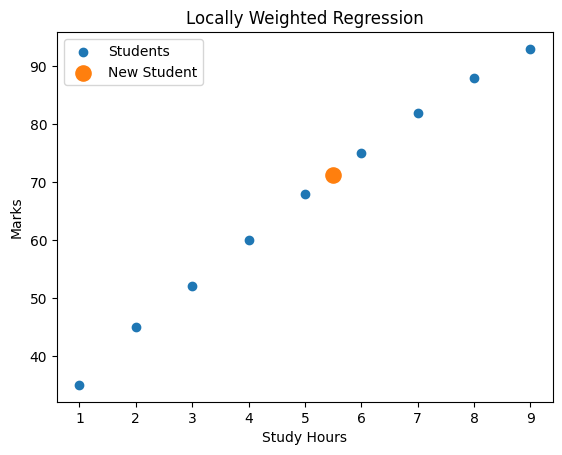

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([35, 45, 52, 60, 68, 75, 82, 88, 93])

# New student
query = 5.5

# Bandwidth
tau = 1.0

# Calculate weights
weights = np.exp(-((X - query) ** 2) / (2 * tau ** 2))

print("Study Hour   Mark   Weight")
print("---------------------------")

for hour, mark, weight in zip(X, y, weights):
    print(f"{hour:^10} {mark:^6} {weight:.3f}")

# Design matrix
X_design = np.column_stack((np.ones(len(X)), X))

# Weighted Linear Regression
W = np.diag(weights)

theta = np.linalg.pinv(
    X_design.T @ W @ X_design
) @ X_design.T @ W @ y

# Prediction
prediction = np.array([1, query]) @ theta

print("\nNew student studies:", query, "hours")
print("Predicted Mark:", round(prediction, 2))

# Plot
plt.scatter(X, y, label="Students")
plt.scatter(query, prediction, s=120, label="New Student")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Locally Weighted Regression")
plt.legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([35, 45, 52, 60, 68, 75, 82, 88, 93])

# RBF centers
centers = np.array([2, 5, 8])

# Width
sigma = 1.5

# Gaussian RBF function
def rbf(x, center):
    return np.exp(-((x - center) ** 2) / (2 * sigma ** 2))

# Convert inputs to RBF features
features = []

for x in X:
    features.append([rbf(x, c) for c in centers])

features = np.array(features)

# Train model
model = LinearRegression()
model.fit(features, y)

# New student
query = 5.5

query_features = np.array(
    [[rbf(query, c) for c in centers]]
)

prediction = model.predict(query_features)

print("RBF Centers:", centers)

print("\nActivation of each center:")
for center, activation in zip(centers, query_features[0]):
    print("Center:", center, "Activation:", round(activation, 3))

print("\nStudent Study Hours:", query)
print("Predicted Mark:", round(prediction[0], 2))

RBF Centers: [2 5 8]

Activation of each center:
Center: 2 Activation: 0.066
Center: 5 Activation: 0.946
Center: 8 Activation: 0.249

Student Study Hours: 5.5
Predicted Mark: 72.28


In [4]:
# Previous cases
cases = [
    {"hours": 2, "mark": 45},
    {"hours": 4, "mark": 60},
    {"hours": 6, "mark": 75},
    {"hours": 8, "mark": 88}
]

# New student
new_hours = 5.5

# Find the most similar previous case
best_case = None
smallest_distance = float("inf")

for case in cases:
    distance = abs(case["hours"] - new_hours)

    print(
        "Previous Case:",
        case["hours"],
        "hours | Distance:",
        distance
    )

    if distance < smallest_distance:
        smallest_distance = distance
        best_case = case

print("\nNew Student:", new_hours, "hours")

print(
    "Most Similar Previous Case:",
    best_case["hours"],
    "hours"
)

print(
    "Previous Student Mark:",
    best_case["mark"]
)

print(
    "Suggested Predicted Mark:",
    best_case["mark"]
)

Previous Case: 2 hours | Distance: 3.5
Previous Case: 4 hours | Distance: 1.5
Previous Case: 6 hours | Distance: 0.5
Previous Case: 8 hours | Distance: 2.5

New Student: 5.5 hours
Most Similar Previous Case: 6 hours
Previous Student Mark: 75
Suggested Predicted Mark: 75
